## CREDIT RISK PREDICTION

By: Nazly Rafa Oktafian Nuzqu

#### BUSINESS PROBLEM UNDERSTANDING

As a Data Scientist at ID/X Partners, I am working on a project for a multifinance/lending company client. The client aims to improve the accuracy of their credit risk assessment and management processes. By developing a robust predictive model, the company can:

- Optimize business decisions regarding loan approvals
- Reduce potential financial losses from defaults
- Better evaluate creditworthiness of loan applicants
- Enhance overall risk management strategy

Dataset Overview
The project uses a Loan Dataset with accompanying Data Dictionary that includes:

- Approved loans data - Loans that were granted to borrowers
- Rejected loans data - Loan applications that were declined
- Credit performance indicators - Historical payment behavior and credit status
- Borrower characteristics - Various attributes of loan applicants

The dataset requires analysis to identify credit performance columns and determine labels (GOOD/BAD credit) based on payment history and delinquency patterns.



#### IMPORT LIBRARIES

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score,fbeta_score,precision_score, recall_score, f1_score, fbeta_score,classification_report, roc_auc_score, accuracy_score
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier


#### LOAD DATASET

Feature Description: https://docs.google.com/spreadsheets/d/1iT1JNOBwU4l616_rnJpo0iny7blZvNBs/edit?gid=1666154857#gid=1666154857 

In [64]:
path = r"C:\Users\Rafa\OneDrive - ypt.or.id\Documents\Data Scientist IDX Partners\FinalProjectIDXPartners/loan_data_2007_2014.csv"
df = pd.read_csv(path)
df.head()

C:\Users\Rafa\AppData\Local\Temp\ipykernel_18044\1246474143.py:2: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### DATA UNDERSTANDING

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 75 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   funded_amnt                  466285 non-null  int64  
 5   funded_amnt_inv              466285 non-null  float64
 6   term                         466285 non-null  object 
 7   int_rate                     466285 non-null  float64
 8   installment                  466285 non-null  float64
 9   grade                        466285 non-null  object 
 10  sub_grade                    466285 non-null  object 
 11  emp_title                    438697 non-null  object 
 12  emp_length                   445277 non-null  object 
 13 

In [66]:
df.columns

Index(['Unnamed: 0', 'id', 'member_id', 'loan_amnt', 'funded_amnt',
       'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade',
       'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc',
       'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url',
       'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti',
       'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths',
       'mths_since_last_delinq', 'mths_since_last_record', 'open_acc',
       'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
       'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt',
       'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
       'total_rec_late_fee', 'recoveries', 'collection_recovery_fee',
       'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d',
       'collections_12_mths_ex_med', 'mths_since_last_major_derog',
       'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint',
       'verificatio

In [67]:
df.describe()

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
count,466285.000000,4.662850e+05,4.662850e+05,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000,4.662810e+05,466285.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,3.960090e+05,0.0,0.0,0.0
mean,233142.000000,1.307973e+07,1.459766e+07,14317.277577,14291.801044,14222.329888,13.829236,432.061201,7.327738e+04,17.218758,...,NaN,NaN,NaN,NaN,NaN,NaN,3.037909e+04,NaN,NaN,NaN
std,134605.029472,1.089371e+07,1.168237e+07,8286.509164,8274.371300,8297.637788,4.357587,243.485550,5.496357e+04,7.851121,...,NaN,NaN,NaN,NaN,NaN,NaN,3.724713e+04,NaN,NaN,NaN
min,0.000000,5.473400e+04,7.047300e+04,500.000000,500.000000,0.000000,5.420000,15.670000,1.896000e+03,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,NaN,NaN,NaN
25%,116571.000000,3.639987e+06,4.379705e+06,8000.000000,8000.000000,8000.000000,10.990000,256.690000,4.500000e+04,11.360000,...,NaN,NaN,NaN,NaN,NaN,NaN,1.350000e+04,NaN,NaN,NaN
50%,233142.000000,1.010790e+07,1.194108e+07,12000.000000,12000.000000,12000.000000,13.660000,379.890000,6.300000e+04,16.870000,...,NaN,NaN,NaN,NaN,NaN,NaN,2.280000e+04,NaN,NaN,NaN
75%,349713.000000,2.073121e+07,2.300154e+07,20000.000000,20000.000000,19950.000000,16.490000,566.580000,8.896000e+04,22.780000,...,NaN,NaN,NaN,NaN,NaN,NaN,3.790000e+04,NaN,NaN,NaN
max,466284.000000,3.809811e+07,4.086083e+07,35000.000000,35000.000000,35000.000000,26.060000,1409.990000,7.500000e+06,39.990000,...,NaN,NaN,NaN,NaN,NaN,NaN,9.999999e+06,NaN,NaN,NaN


In [68]:
df.shape

(466285, 75)

In [69]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct
}).sort_values('Missing (%)', ascending=False)
print(missing_df[missing_df['Missing Count'] > 0])

                             Missing Count  Missing (%)
max_bal_bc                          466285   100.000000
open_rv_24m                         466285   100.000000
inq_fi                              466285   100.000000
open_rv_12m                         466285   100.000000
il_util                             466285   100.000000
mths_since_rcnt_il                  466285   100.000000
total_bal_il                        466285   100.000000
open_il_24m                         466285   100.000000
open_il_12m                         466285   100.000000
open_il_6m                          466285   100.000000
open_acc_6m                         466285   100.000000
dti_joint                           466285   100.000000
annual_inc_joint                    466285   100.000000
verification_status_joint           466285   100.000000
all_util                            466285   100.000000
inq_last_12m                        466285   100.000000
total_cu_tl                         466285   100

Dalam dataset di atas, terdapat beberapa feature yang memiliki persentase missing values yang tinggi bahkan 100%, untuk handling missing values pada feature yang memiliki persentase > 30% akan di drop / hapus. Kemudian untuk feature dengan persentase missing values < 30% akan dilakukan imputasi menggunakan median / mean.

In [70]:
df.duplicated().sum()

np.int64(0)

Tidak terdapat duplikasi data pada dataset tersebut

In [71]:
df['loan_status'].value_counts()

loan_status
Current                                                224226
Fully Paid                                             184739
Charged Off                                             42475
Late (31-120 days)                                       6900
In Grace Period                                          3146
Does not meet the credit policy. Status:Fully Paid       1988
Late (16-30 days)                                        1218
Default                                                   832
Does not meet the credit policy. Status:Charged Off       761
Name: count, dtype: int64

Analisis isi / nilai dari feature 'loan_status' sebagai acuan penentuan target dapat dikelompokkan menjadi good / bad credit risk prediction. Berdasarkan value dari loan status tersebut, dapat dikelompokkan untuk nilai target seperti berikut:

Good (0): 
- Fully Paid
- Does not meet the credit policy. Status: Fully Paid

Bad (1): 
- Deafault
- Charged Off
- Does not meet the credit policy. Status: Charged Off
- Late (31-120 days)

#### EXPLORATORY DATA ANALYSIS

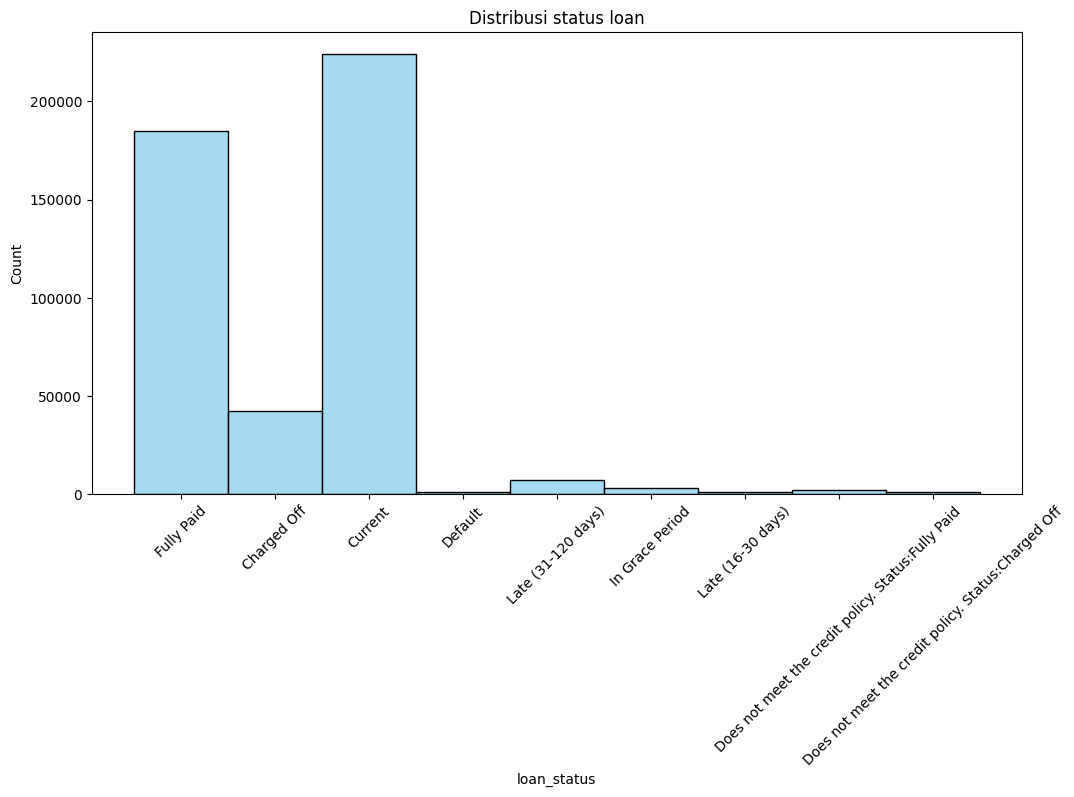

loan_status
Current                                                224226
Fully Paid                                             184739
Charged Off                                             42475
Late (31-120 days)                                       6900
In Grace Period                                          3146
Does not meet the credit policy. Status:Fully Paid       1988
Late (16-30 days)                                        1218
Default                                                   832
Does not meet the credit policy. Status:Charged Off       761
Name: count, dtype: int64


In [72]:
plt.figure(figsize=(12,6))
sns.histplot(df['loan_status'],bins=8, color='skyblue')
plt.title('Distribusi status loan')
plt.xticks(rotation=45)
plt.show()

print(df['loan_status'].value_counts())

In [73]:
df_model = df
df_model.head()

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [75]:
df_model.drop([
    'id', 'member_id', 'url', 'title', 'zip_code', 'emp_title',
    'recoveries', 'collection_recovery_fee', 'application_type',
    'issue_d', 'pymnt_plan', 'out_prncp', 'out_prncp_inv',
    'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp',
    'total_rec_int', 'total_rec_late_fee', 'last_pymnt_d',
    'last_pymnt_amnt', 'last_credit_pull_d', 'sub_grade',
    'funded_amnt', 'funded_amnt_inv', 'policy_code',
    'addr_state', 'earliest_cr_line','Unnamed: 0',

    # missing value
    'max_bal_bc', 'open_rv_24m', 'inq_fi', 'open_rv_12m',
    'il_util', 'mths_since_rcnt_il', 'total_bal_il',
    'open_il_24m', 'open_il_12m', 'open_il_6m',
    'open_acc_6m', 'dti_joint', 'annual_inc_joint',
    'verification_status_joint', 'all_util', 'inq_last_12m',
    'total_cu_tl', 'mths_since_last_record',
    'mths_since_last_major_derog', 'desc',
    'mths_since_last_delinq'

], axis=1, inplace=True)

Menghapus feature yang tidak berguna untuk menentukan hasil prediksi seperti fetaure menggunakan 'id', 'link' ataupun missing values dengan persentase > 30%

In [76]:
df_model.shape

(466285, 26)

In [77]:
df_model.isnull().sum()

loan_amnt                          0
term                               0
int_rate                           0
installment                        0
grade                              0
emp_length                     21008
home_ownership                     0
annual_inc                         4
verification_status                0
loan_status                        0
purpose                            0
dti                                0
delinq_2yrs                       29
inq_last_6mths                    29
open_acc                          29
pub_rec                           29
revol_bal                          0
revol_util                       340
total_acc                         29
initial_list_status                0
next_pymnt_d                  227214
collections_12_mths_ex_med       145
acc_now_delinq                    29
tot_coll_amt                   70276
tot_cur_bal                    70276
total_rev_hi_lim               70276
dtype: int64

In [78]:
df_model['loan_label'] = np.where(df_model.loc[:, 'loan_status'].isin(['Charged Off', 'Default', 'Late (31-120 days)','Does not meet the credit policy. Status:Charged Off']), 0, 1)
df_model.drop(columns = ['loan_status'], inplace = True)
     

In [79]:
print(df_model['loan_label'].value_counts())

loan_label
1    415317
0     50968
Name: count, dtype: int64


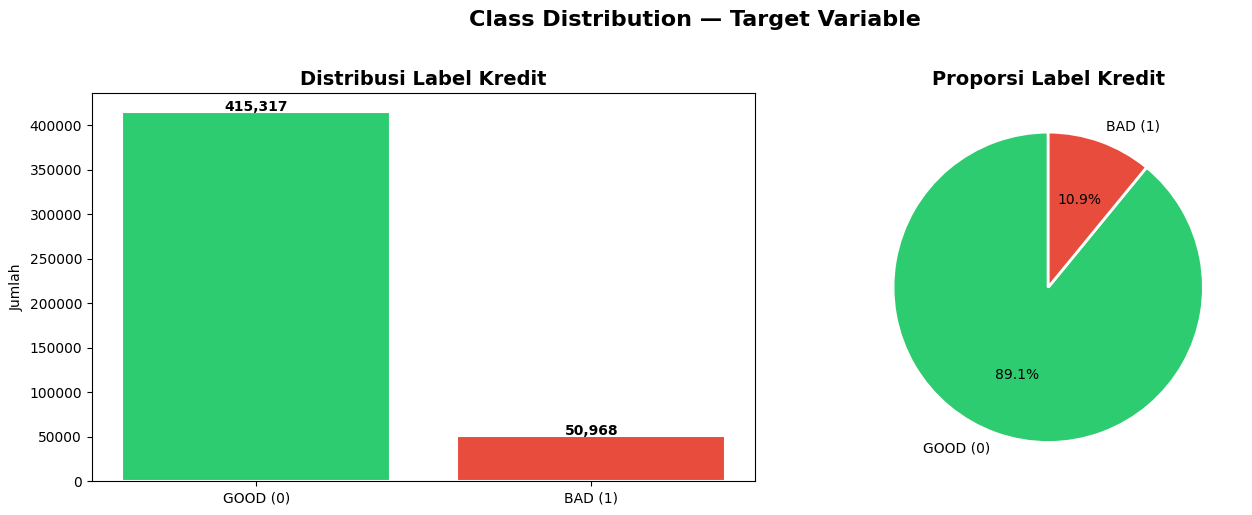

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
counts = df['loan_label'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['GOOD (0)', 'BAD (1)'], counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribusi Label Kredit', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Jumlah')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['GOOD (0)', 'BAD (1)'],
            colors=colors, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporsi Label Kredit', fontsize=14, fontweight='bold')

plt.suptitle('Class Distribution — Target Variable', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Dari visualisasi di atas ditampilkan distribusi data dari pengelompokkan nilai good dan bad, dimana proporsi label bad sendiri hanya memiliki **10.9%**, sedangkan untuk nilai good ada pada **89.1%**. Ini menandakan adanya **data imbalance**, sehingga perlu dilakukan oversampling (SMOTE) untuk label bad, agar tidak terjadi bias dalam proses training model.

C:\Users\Rafa\AppData\Local\Temp\ipykernel_18044\2247804311.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([good, bad], labels=['GOOD', 'BAD'], patch_artist=True,


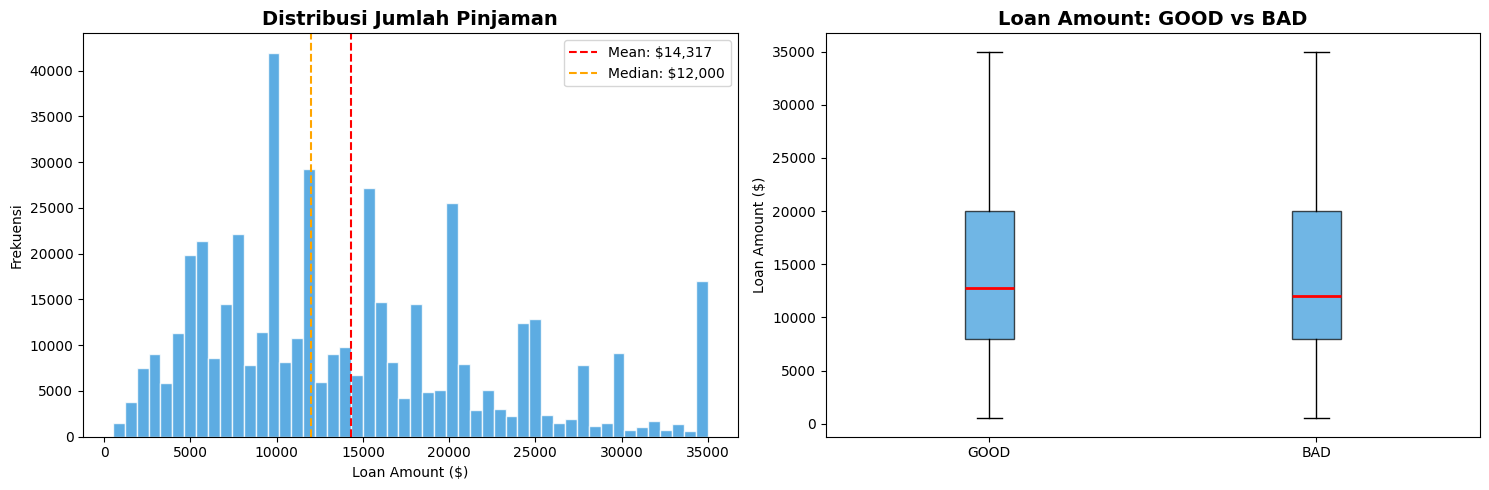

Mean  Loan Amount: $14,317.28
Median Loan Amount: $12,000.00


In [81]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram keseluruhan
axes[0].hist(df_model['loan_amnt'], bins=50, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribusi Jumlah Pinjaman', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Loan Amount ($)')
axes[0].set_ylabel('Frekuensi')
axes[0].axvline(df_model['loan_amnt'].mean(), color='red', linestyle='--', label=f'Mean: ${df_model["loan_amnt"].mean():,.0f}')
axes[0].axvline(df_model['loan_amnt'].median(), color='orange', linestyle='--', label=f'Median: ${df_model["loan_amnt"].median():,.0f}')
axes[0].legend()

# Boxplot by label
good = df_model[df_model['loan_label']==0]['loan_amnt']
bad  = df_model[df_model['loan_label']==1]['loan_amnt']
axes[1].boxplot([good, bad], labels=['GOOD', 'BAD'], patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Loan Amount: GOOD vs BAD', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Loan Amount ($)')

plt.tight_layout()
plt.show()

print(f'Mean  Loan Amount: ${df_model["loan_amnt"].mean():,.2f}')
print(f'Median Loan Amount: ${df_model["loan_amnt"].median():,.2f}')

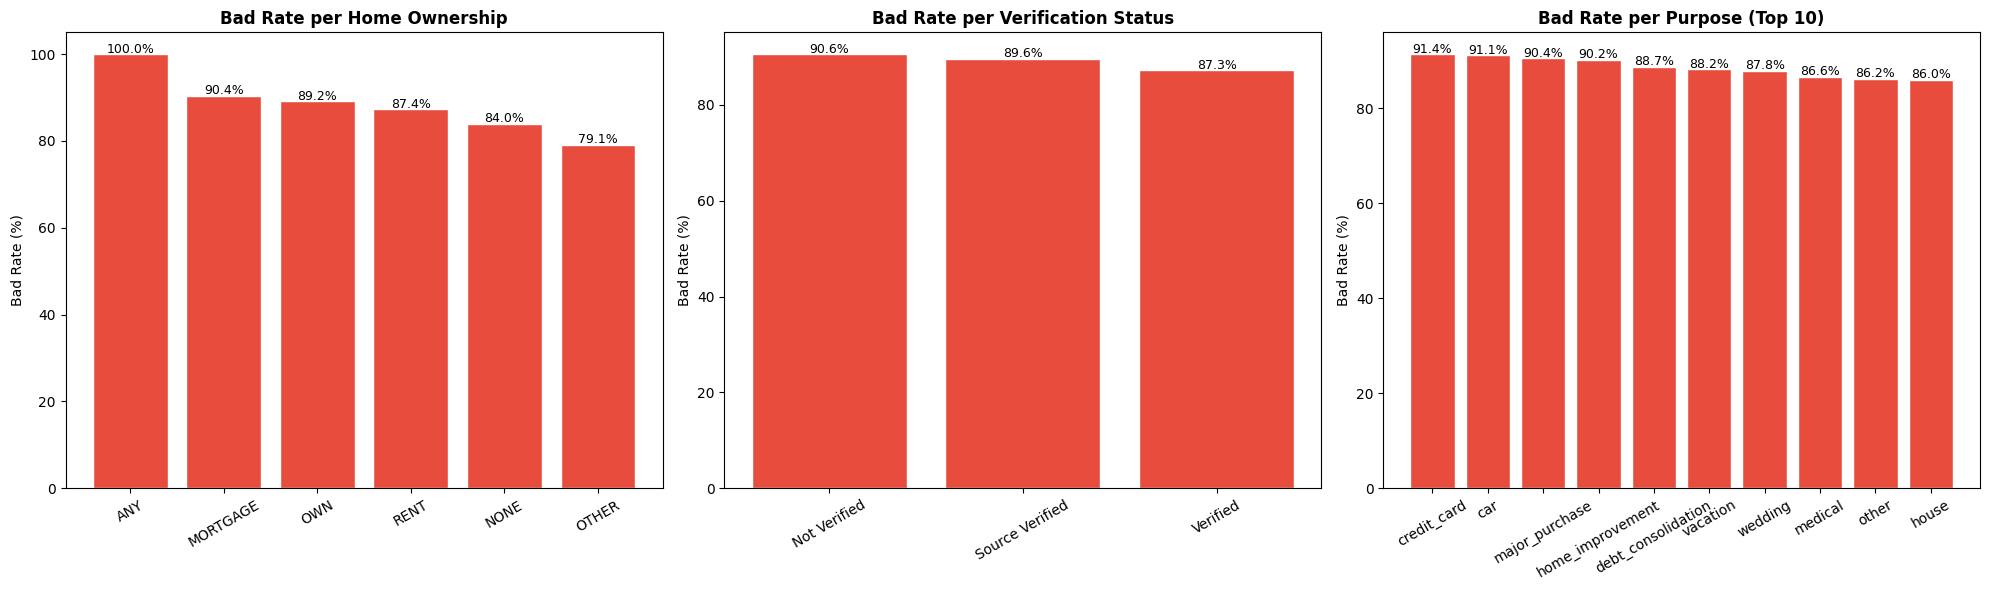

In [82]:
# Home Ownership, Verification Status, Purpose
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

def plot_bad_rate_cat(col, ax, title, top_n=None):
    data = df_model.groupby(col)['loan_label'].mean().sort_values(ascending=False) * 100
    if top_n:
        data = data.head(top_n)
    colors_bar = ['#e74c3c' if v > 15 else '#f39c12' if v > 10 else '#2ecc71' for v in data.values]
    bars = ax.bar(data.index, data.values, color=colors_bar, edgecolor='white')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Bad Rate (%)')
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, data.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}%', ha='center', fontsize=9)

plot_bad_rate_cat('home_ownership', axes[0], 'Bad Rate per Home Ownership')
plot_bad_rate_cat('verification_status', axes[1], 'Bad Rate per Verification Status')
plot_bad_rate_cat('purpose', axes[2], 'Bad Rate per Purpose (Top 10)', top_n=10)

plt.tight_layout()
plt.show()

In [83]:
df_model.columns

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'emp_length',
       'home_ownership', 'annual_inc', 'verification_status', 'purpose', 'dti',
       'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'initial_list_status', 'next_pymnt_d',
       'collections_12_mths_ex_med', 'acc_now_delinq', 'tot_coll_amt',
       'tot_cur_bal', 'total_rev_hi_lim', 'loan_label'],
      dtype='object')